In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("lab03.ipynb")

# E7: Lab Assignment 03 - Functions & Conditional Statements

You must submit the lab to Gradescope by the due date. You will submit the zip file produced by running the final cell of the assignment.

## Instructions

**Run the first cell, Initialize Otter**, to import the autograder and submission exporter.

Throughout the assignment, replace `...` with your answers. We use `...` as a placeholder and these should be deleted and replaced with your answers.

Any part listed as a "<font color='red'>**Question**</font>" should be answered to receive credit.

**Please save your work after every question!**

To read the documentation on a Python function, you can type `help()` and add the function name between parentheses.

## Score Breakdown
Question   | Points
:---       | --:
1          | 2
2.0 – 2.3  | 4
3.0 – 3.3  | 5
4.0 – 4.3  | 7
5          | 4
6          | 3
Total      | 25

**Run the cell below**, to import the required modules.

In [2]:
# Please run this cell, and do not modify the contents
# Hashing first
import hashlib
def get_hash(num):
    """Helper function for assessing correctness"""
    return hashlib.md5(str(num).encode()).hexdigest()


import math
import numpy as np
import matplotlib.pyplot as plt

## Question 1: Roots

Write a Python function that calculates the roots of a quadratic equation $ax^2+bx+
c = 0$ of unknown $x$, using the quadratic formula below. 

$$x = \frac{-b\pm \sqrt{b^2-4ac}}{2a}$$

The function output should be a two element tuple. The first element, `elem_1`, should be the root computed by setting the $\pm$ to $+$, and the second element, `elem_2`, should be the root computed by setting the $\pm$ to $-$.

The discriminant is $b^2 - 4ac$. You may assume $b^2 - 4ac \ge 0$.

Test your `solve_quadratic()` function to calculate the roots of the following equation: $6x^2-17x+12 = 0$ and assign the output to `q1`. Feel free to try it for other inputs.

```PYTHON
Examples:

>>> solve_quadratic(1, 2, 1) 
(-1.0, -1.0)

>>> solve_quadratic(1, -3.5, 3) 
(2.0, 1.5)

>>> solve_quadratic(1, 0, -0.25) 
(0.5, -0.5)
```

In [3]:
# ANSWER CELL
def solve_quadratic(a, b, c):
    """
    Arguments
    ---------
    a : coefficient of x**2
    b : coefficient of x
    c : constant
    
    Returns
    -------
    elem_1 : larger root of quadratic equation
    elem_2 : smaller root of quadratic equation
    """
    discriminant = math.sqrt(b*b-4*a*c) # SOLUTION
    elem_1 = (-b+discriminant)/(2*a) # SOLUTION
    elem_2 = (-b-discriminant)/(2*a) # SOLUTION
    return elem_1, elem_2 

In [4]:
# TEST YOUR FUNCTION HERE
q1 = solve_quadratic(6,-17,12) # SOLUTION

print(f'Roots: {q1}')

Roots: (1.5, 1.3333333333333333)


In [5]:
grader.check("q1")

q1 results: All test cases passed!

## Question 2

Carbon dating is a method for determining the age of an object containing the radioisotope carbon-14. Since carbon-14 is subject to radioactive decay, the number of carbon-14 atoms in a sample will decay over time according to the following exponential decay law:

$$ N(t) = N_0 e^{-\lambda t} $$

where $N_0$ is the number of atoms of the isotope in the original sample at time 0, $N(t)$ is the remaining number of atoms after a time $t$, $\lambda$ is the exponential decay constant and $t$ is the time.

### Question 2.0

Write a function that calculates and returns the remaining fraction of carbon-14 in a sample after a certain amount of time (in years). The remaining fraction is defined as the ratio of the number of atoms at the present time ($N(t)$) to the initial number of atoms ($N_0$). You can re-arrange the decay formula above to find an expression for this ratio.

Assume $\lambda = 0.00012097 \: \text{years}^{-1}$.

**Note that** `lambda` is a reserved keyword in Python, so it cannot be used as a variable name.

Test your new `c14_dating()` function for `time = 1000` years and assign the output to `q2_0`. Feel free to try it for other inputs.

```PYTHON
Examples:

>>> c14_dating(100)
0.987975874554016

>>> c14_dating(1000)
0.8860605410103827

>>> c14_dating(5000)
0.5461563439473499
```

In [6]:
# ANSWER CELL
def c14_dating(time):
    ratio = math.e**(-time*0.00012097) # SOLUTION
    return ratio

In [7]:
# TEST YOUR FUNCTION HERE
q2_0 = c14_dating(1000) # SOLUTION

print(f'The remaining fraction is: {q2_0}')

The remaining fraction is: 0.8860605410103827


In [8]:
grader.check("q2.0")

q2.0 results: All test cases passed!

### Question 2.1

Create a simpler version of Q2.0 by writing a lambda function called `lambda_c14_dating`. Your lambda function should perform the same calculation as Q2.0 with `time` as the input and fraction remaining as the output. Keep the decay constant as $\lambda = 0.00012097 \: \text{years}^{-1}$

Test your new `lambda_c14_dating` function for `time = 1000` years and assign the output to `q2_1`. Feel free to try it for other inputs.

In [9]:
# ANSWER CELL
lambda_c14_dating = lambda time : math.e**(-time*0.00012097) # SOLUTION

In [10]:
# TEST YOUR FUNCTION HERE
q2_1 = lambda_c14_dating(1) # SOLUTION

print(f'The remaining fraction is: {q2_1}')

The remaining fraction is: 0.9998790373165755


In [11]:
grader.check("q2.1")

q2.1 results: All test cases passed!

### Question 2.2

Now create a more general version of the function in Q2.0 and name the new function `exp_decay()`. This new function will perform the same calculation as `c14_dating()` but will include two input arguments: `time` for $t$ and `decay_constant` for $\lambda$, the exponential decay constant. Call the argument for $\lambda$ `decay_constant`. Set the default value for `decay_constant` equal to the exponential decay constant for c-14, which is 0.00012097.

Create your function such that it accepts a NumPy array for `time`, not just scalar values. Note that many functions within the `math` module only accept scalar values as input.

Test your new `exp_decay()` function for `time = 1000` years and `decay_constant = 0.001` assign the output to `q2_2`. Feel free to try it for other inputs.
                                                                                                                                           
```PYTHON
Examples:

>>> exp_decay(100, 0.005)
0.6065306597126334

>>> exp_decay(1, 1)
0.36787944117144233
                                                                                                                                           
>>> exp_decay(np.array([5000, 6000]), 0.001) # Function should work with a NumPy array for time
array([0.00673795, 0.00247875])
                                                                                                                     
>>> exp_decay(1000) # Function should have a default value for decay_constant
0.8860605410103827
                                                                                                                                           
>>> exp_decay(np.array([5000, 6000]))
array([0.54615634, 0.48392759])      
```

In [12]:
# ANSWER CELL
# BEGIN SOLUTION
def exp_decay(time,decay_constant=0.00012097):
    ratio = math.e**(-time*decay_constant)
    return ratio
# END SOLUTION

In [13]:
# TEST YOUR FUNCTION HERE
q2_2 = exp_decay(1000, 0.001) # SOLUTION

print(f'The remaining fraction is: {q2_2}')

The remaining fraction is: 0.36787944117144233


In [14]:
grader.check("q2.2")

q2.2 results: All test cases passed!

### Question 2.3

Create a NumPy array that includes time between 0 and 10,000, inclusive, with increments of 100: [0, 100, 200, .., 9800, 9900, 10000]. Save the array as `time_array`.

Then, use your `exp_decay()` function to compute the remaining fraction of carbon-14 over this range of time. Use the default value for `decay_constant`. Assign the values of the fraction of carbon-14 remaining to `c14frac_array`.

In [15]:
# ANSWER CELL
time_array = np.arange(0,10001,100) # SOLUTION
c14frac_array = exp_decay(time_array) # SOLUTION

In [16]:
# Run this cell to print the results
print(time_array) 
print(c14frac_array) 

[    0   100   200   300   400   500   600   700   800   900  1000  1100
  1200  1300  1400  1500  1600  1700  1800  1900  2000  2100  2200  2300
  2400  2500  2600  2700  2800  2900  3000  3100  3200  3300  3400  3500
  3600  3700  3800  3900  4000  4100  4200  4300  4400  4500  4600  4700
  4800  4900  5000  5100  5200  5300  5400  5500  5600  5700  5800  5900
  6000  6100  6200  6300  6400  6500  6600  6700  6800  6900  7000  7100
  7200  7300  7400  7500  7600  7700  7800  7900  8000  8100  8200  8300
  8400  8500  8600  8700  8800  8900  9000  9100  9200  9300  9400  9500
  9600  9700  9800  9900 10000]
[1.         0.98797587 0.97609633 0.96435962 0.95276404 0.94130789
 0.92998948 0.91880717 0.90775932 0.89684431 0.88606054 0.87540644
 0.86488044 0.85448101 0.84420662 0.83405578 0.82402699 0.81411878
 0.80432972 0.79465835 0.78510328 0.7756631  0.76633643 0.75712191
 0.74801818 0.73902391 0.7301378  0.72135853 0.71268482 0.70411541
 0.69564904 0.68728447 0.67902047 0.67085585 0.66

In [17]:
grader.check("q2.3")

q2.3 results: All test cases passed!

## Question 3

A ball is launched in the air at an angle $\theta$ (expressed in degrees) from the x-axis and with initial velocity $v_o$ from an initial position of coordinates $(x_0, y_0)$ as illustrated below: 

<center> <img src="resources/ball.jpg" style="width: 300px;"/> </center>
<center> Figure 1: Ball launching at angle $\theta$ from the x-axis with initial velocity $v_0$ </center>

The equations describing the motion (i.e. the position of the ball $(x, y)$ as a function of time $t$) are:

$$ x(t) = x_0 + v_0 t \cos(\theta) \\ $$
$$ y(t) = y_0 + v_0 t \sin(\theta) - \dfrac{1}{2}gt^2 $$

where $g$ is the gravitational acceleration ($g = 9.81\,\text{m}/\text{s}^2$)

### Question 3.0

Write a function named `proj_time()` that calculates and returns the time at which the ball reaches the ground. This function has the following input arguments (use the same argument names):
* `y0`, which is the initial $y$ position (scalar)
* `v0`, which is the initial velocity (scalar)
* `theta`, which is the launching angle in degrees (scalar)

Note that when the ball hits the ground, $y = 0$. So, to find the time at which the ball reaches the ground, you have to solve the quadratic equation: 

$$ - \frac{1}{2}gt^2 + v_0 t \sin(\theta)  + y_0 = 0 $$ 

You should have already defined a function that solves a quadratic equation (function `solve_quadratic()`, refer to Question 1).

Inside `proj_time()`, call the function `solve_quadratic()` with the correct inputs based on the quadratic equation above.  Recall that `solve_quadratic()` returns two elements. The correct solution for the time at which the ball reaches the ground is the second element, `elem_2`, for which the root is computed by setting the $\pm$ to $-$. Your function `proj_time()` should only return one solution, the correct one.

Use your new `proj_time()` function for `y0 = 0` meters, `v0 = 15` m/s, `theta = 40` degrees and assign the output to `q3_0`. Feel free to try it for other input values. 


Note that trigonometric functions such as `math.cos()` and `math.sin()` assume that the angle is in **radians**. However, `theta` is given in degrees. You can convert the angle to radians using `math.radians()`, which takes as input an angle in degrees and converts it to radians.

```PYTHON
Examples:

>>> proj_time(y0=0, v0=10, theta=25)
0.8616070575753302

>>> proj_time(y0=10, v0=15, theta=20)
2.043568443579824                                                                                                                                      

>>> proj_time(y0=15, v0=20, theta=45)
3.707950478020033
```

In [18]:
# run this cell to create a global variable g, but make sure you don't have any other global variables also named g
g = 9.81

In [19]:
# ANSWER CELL
# BEGIN SOLUTION
def proj_time(y0, v0, theta):
    b = v0 * math.sin(math.radians(theta))
    _ , time = solve_quadratic(-1/2*g,b,y0)
    return time
# END SOLUTION

In [20]:
# TEST YOUR FUNCTION HERE
q3_0 = proj_time(0, 15, 40) # SOLUTION

print(f'The time at which the ball reaches the ground is: {q3_0} s')

The time at which the ball reaches the ground is: 1.9657113446071535 s


In [21]:
grader.check("q3.0")

q3.0 results: All test cases passed!

### Question 3.1 

Write a function named `proj_distance()` that calculates and returns the horizontal distance of the ball when it reaches the ground. This function has the following input arguments (use the same argument names):
* `x0`, which is the initial $x$ position (scalar)
* `y0`, which is the initial $y$ position (scalar)
* `v0`, which is the initial velocity (scalar)
* `theta`, which is the launching angle in degrees (scalar)

You can first solve for the time when the ball hits the ground using the function above, `proj_time()`, and then use this time in the following equation to get the horizontal distance traveled: $$ x(t) = x_0 + v_0 t \cos(\theta) $$

Set the default value of `x0` equal to 0.

Test your new `proj_distance()` function for `x0 = 0` meters, `y0 = 0` meters, `v0 = 15` m/s, `theta = 40` degrees and assign the output to `q3_1`. Feel free to try it for other input values. 

```PYTHON
Examples:

>>> proj_distance(y0=0, v0=15, theta=40, x0=2)
24.587333784683665

>>> proj_distance(y0=10, v0=10, theta=25, x0=10)
27.4212434401576                                                                                                                                     

>>> proj_distance(y0=15, v0=10, theta=45) # Function should have a default value for x0
18.47155402520493
```

In [22]:
# ANSWER CELL
# BEGIN SOLUTION
def proj_distance(y0, v0, theta, x0=0):
    time = proj_time(y0, v0, theta)
    dist = x0 + v0 * time * math.cos(math.radians(theta))
    return dist
# END SOLUTION

In [23]:
# TEST YOUR FUNCTION HERE
q3_1 = proj_distance(0, 15, 40) # SOLUTION

print(f'The horizontal distance of the ball when it reaches the ground is: {q3_1} m')

The horizontal distance of the ball when it reaches the ground is: 22.587333784683665 m


In [24]:
grader.check("q3.1")

q3.1 results: All test cases passed!

### Question 3.2

Calculate the horizontal distance traveled by a ball starting at $5\,\text{m}$ above the ground, with a velocity of $1\,\text{m}/\text{s}$ at an angle of 30 degrees above horizontal. Store the value as `q3_2`.

In [25]:
# ANSWER CELL
g = 9.81 # SOLUTION NO PROMPT
q3_2 = proj_distance(5, 1, 30) # SOLUTION

print(f'The horizontal distance traveled by the ball is: {q3_2} m')

The horizontal distance traveled by the ball is: 0.9196251241440149 m


In [26]:
grader.check("q3.2")

q3.2 results: All test cases passed!

### Question 3.3

Reassign the gravitational acceleration variable, `g`, to $32.2\,\text{ft}/\text{s}^2$. Then calculate the horizontal distance traveled by a ball starting at $5\,\text{ft}$ above the ground, with a velocity of $1\,\text{ft}/\text{s}$ at an angle of 30 degrees above horizontal. Store the value as `q3_3`.

In [27]:
# ANSWER CELL
# BEGIN SOLUTION
g = 32.2
q3_3 = proj_distance(5, 1, 30) 
q3_3
# END SOLUTION

0.4962520035072661

In [28]:
# Do not edit this cell. Run it to reassign g to 9.81 m/s^2.
g = 9.81

In [29]:
grader.check("q3.3")

q3.3 results: All test cases passed!

<div class="alert alert-block alert-warning"> <b>NOTE!</b> The rest of the lab involves working with conditional statements. If we haven't covered this topic yet and you have no prior experience with it, please wait until after the next lecture to continue the assignment. </div>

## Question 4: Box on a Slope

A box with mass $m$ is sitting on a sloped surface is influenced by gravity in a way that pulls the box down the slope. Friction resists this effect, with the frictional force being proportional to the normal force between the box and the slope.

<center> <img src="https://stickmanphysics.com/wp-content/uploads/2023/12/Incline-FBD-Box.jpg" style="width: 500px;"/> </center>
<center> <br> Figure 2: Free body diagram of a box on an inclined surface </center>

where:
* $F_w$ is the weight (force due to gravity), where $F_w = mg$
* $F_N$ is the normal force, where $F_N = \cos({\theta}) \ mg$
* $F_f$ is the frictional force

The frictional force is proportional to the normal force according to the friction coefficient $f$:

$$F_f = f F_N = f \cos({\theta}) \ mg$$

As the slope gets steeper, eventually the frictional force will not be sufficient to keep the box in place and it will slide down the slope. If you know the friction coefficient $f$, you can solve for the critical value of the slope that will cause the box to slide:

$$\theta_{cri} = \arctan(f)$$

### Question 4.0

Write a function named `cri_angle()` that calculates and returns the critical angle that will cause the box to slide. This function has the following input argument (use the same argument name):
* `f`, which is the friction coefficient (scalar)

The returned critical angle should be in **degrees**.

Note that trigonometric functions usually assume that the angle is in radians. You can convert the angle to degrees using `math.degrees()`.

Test your new `cri_angle()` function for `f = 0.5` and assign the output to `q4_0`. Feel free to try it for other input values.

```PYTHON
Examples:

>>> cri_angle(1)
45.0

>>> cri_angle(0.4)
21.80140948635181                                                                                                                                    

>>> cri_angle(0.2)
11.309932474020215
```

In [30]:
# ANSWER CELL
# BEGIN SOLUTION
def cri_angle(f):
    return math.degrees(math.atan(f))
# END SOLUTION

In [31]:
# TEST YOUR FUNCTION HERE
q4_0 = cri_angle(0.5) # SOLUTION

print(f'The angle that will cause the box to start sliding is: {q4_0} degrees')

The angle that will cause the box to start sliding is: 26.56505117707799 degrees


In [32]:
grader.check("q4.0")

q4.0 results: All test cases passed!

### Question 4.1

The box will begin to slide when the actual angle of the slope is equal or greater than the critical angle.

Write a function named `box_pred()` that predicts whether or not a box will slide. This function has the following input arguments (use the same argument names):
* `f`, which is the friction coefficient (scalar)
* `theta`, which is the actual angle of the slope in degrees (scalar)

Your function should make a prediction and should return one of the following strings:

'The box will slide.' or 'The box will not slide.'

Note that your function should return the string, not print it.

Test your new `box_pred()` function for `f = 0.5` and `theta = 30` and assign the output to `q4_1`. Feel free to try it for other input values. 

```PYTHON
Examples:

>>> box_pred(f=0.7, theta=32.0)
'The box will not slide.'

>>> box_pred(f=0.6, theta=32.0)
'The box will slide.'                                                                                                                                  

>>> box_pred(f=0.6248693519093275, theta=32.0)
'The box will slide.'  
```

In [33]:
# ANSWER CELL
# BEGIN SOLUTION
def box_pred(f, theta):
    if theta >= cri_angle(f):
        return 'The box will slide.'
    else:
        return 'The box will not slide.'
# END SOLUTION

In [34]:
# TEST YOUR FUNCTION HERE
q4_1 = box_pred(f=0.5, theta=30) # SOLUTION

print(q4_1)

The box will slide.


In [35]:
grader.check("q4.1")

q4.1 results: All test cases passed!

### Question 4.2

Create a simpler version of Q4.1 by writing a lambda function called `lambda_box_pred`. Your lambda function should return the same string as Q4.1 with `f` and `theta` as inputs.

Note that to be able to implement this as a lambda function, you may want to use ternary operators. Refer to the lecture notes for more details.

Test your new `lambda_box_pred` function for `f = 0.5` and `theta = 30` and assign the output to `q4_2`. Feel free to try it for other input values. 

In [36]:
# ANSWER CELL
# BEGIN SOLUTION
lambda_box_pred = lambda f, theta: 'The box will slide.' if theta >= cri_angle(f) else  'The box will not slide.'
# END SOLUTION

In [37]:
# TEST YOUR FUNCTION HERE
q4_2 = lambda_box_pred(f=0.5, theta=30) # SOLUTION

print(q4_2)

The box will slide.


In [38]:
grader.check("q4.2")

q4.2 results: All test cases passed!

### Question 4.3

Instead of calculating the critical angle beyond which the slope will slide, we can calculate the critical friction coefficient below which the box will slide. 

As the friction coefficient decreases, eventually the frictional force will not be sufficient to keep the box in place and it will slide down the slope. If you know the angle of the slope $\theta$, you can solve for the critical value of the friction coefficient that will cause the box to slide:

$$f_{cri} = \tan(\theta)$$

Next, you will write a more general function that will either return $f_{cri}$ or $\theta_{cri}$ or return whether the box will slide or not.

Write a function named `box_pred_any()`, which has the following input arguments (use the same argument names):
* `f`, which is either a string `'?'` or a scalar of the actual friction coefficient
* `theta`, which is either a string `'?'` or a scalar of the actual slope in degrees

Your function should return one of the following strings:
1. If `f = '?'`, it should solve for $f_{cri}$ based on the slope angle and return: 
> 'If f is less than [value], the box will slide.'

> where [value] should be replaced by $f_{cri}$. Round $f_{cri}$ to three digits after the decimal point.

2. If `theta = '?'`, it should solve for $\theta_{cri}$ based on the friction coefficient and return: 
> 'If theta is greater than [value] degrees, the box will slide.'

> where [value] should be replaced by $\theta_{cri}$ in **degrees**. Round $\theta_{cri}$ to three digits after the decimal point.

3. If both `f` and `theta` have actual values (i.e., none are equal to `'?'`), your function should make a prediction and should return either:
> 'The box will slide.' or 'The box will not slide.'

4. If both `f` and `theta` are equal to `'?'`, your function should return:
> 'Either f or theta should have a numeric value.'

Note that your function should return the string, not print it.

Test your new `box_pred_any()` function for `f = 0.5` and `theta = '?'` and assign the output to `q4_3`. Feel free to try it for other input values. 

```PYTHON
Examples:

>>> box_pred_any(f=0.5, theta=30) # both f and theta have numeric values
'The box will slide.'

>>> box_pred_any(f=0.6, theta=29) # both f and theta have numeric values
'The box will not slide.'                                                                                                                              

>>> box_pred_any(f='?', theta='?') # both f and theta are '?'
'Either f or theta should have a numeric value.'

>>> box_pred_any(f='?', theta=25) # only f is '?'
'If f is less than 0.466, the box will slide.'

>>> box_pred_any(f=0.25, theta='?') # only theta is '?'
'If theta is greater than 14.036 degrees, the box will slide.'
```

In [39]:
# ANSWER CELL
# BEGIN SOLUTION
def box_pred_any(f, theta):
    if f=='?' and theta!='?':
        return f'If f is less than {round(math.tan(math.radians(theta)),3)}, the box will slide.'
    elif f!='?' and theta=='?':
        return f'If theta is greater than {round(cri_angle(f),3)} degrees, the box will slide.'
    elif f!='?' and theta!='?':
        return box_pred(f, theta)
    else:
        return 'Either f or theta should have a numeric value.'
# END SOLUTION

In [40]:
# TEST YOUR FUNCTION HERE
q4_3 = box_pred_any(f=0.5, theta='?') # SOLUTION

print(q4_3)

If theta is greater than 26.565 degrees, the box will slide.


In [41]:
grader.check("q4.3")

q4.3 results: All test cases passed!

## Question 5: Best Electricity Plan

Many electric companies offer different pricing plans, allowing users to choose the plan that best suits their usage patterns to reduce their electricity bills.

Consider the following three different plans where the price of electricity varies by the time of day. The goal is to find the cheapest plan for a given usage pattern.

**Plan 1:**
This is a flat rate plan with price $\$1.25$ per kilowatt-hour.

**Plan 2:**
This is a tiered rate plan with the following pricing: $\begin{cases} \$0.50 \text{ per kilowatt-hour,} & \text{12 am} \leq t < \text{8 am} \\ \$2.00 \text{ per kilowatt-hour,} & \text{8 am} \leq t < \text{6 pm} \\ \$0.50 \text{ per kilowatt-hour,} & \text{6 pm} \leq t < \text{12 am}\end{cases}$

**Plan 3:**
This is another tiered rate plan with the following pricing: $\begin{cases} \$0.25 \text{ per kilowatt-hour,} & \text{12 am} \leq t < \text{4 am} \\ \$0.75 \text{ per kilowatt-hour,} & \text{4 am} \leq t < \text{7 am} \\ \$1.50 \text{ per kilowatt-hour,} & \text{7 am} \leq t < \text{7 pm} \\ \$0.75 \text{ per kilowatt-hour,} & \text{7 pm} \leq t < \text{10 pm} \\ \$0.25 \text{ per kilowatt-hour,} & \text{10 pm} \leq t < \text{12 am}\end{cases}$

Write a function named `best_plan()` that calculates the total cost for each plan and identifies the cheapest one. The function has the following input argument (use the same argument names):
* `usage`, which is a one-dimensional data structure with 24 numeric values representing the electricity usage in kilowatt-hours for each hour of the day
    * `usage[0]` corresponds to the usage between 12 am and 1 am
    * `usage[1]` corresponds to the usage between 1 am and 2 am
    * $\dots$
    * `usage[23]` (or `usage[-1]`) corresponds to the usage between 11 pm and 12 am

Your function should return a tuple with the following (in this order):
1. `best_price`: The total cost of electricity usage for the cheapest plan
2. `best_plan`: A string indicating the name of the cheapest plan (`'Plan 1'`, `'Plan 2'`, or `'Plan 3'`)

If two plans result in the same lowest total cost, choose the simpler plan (i.e., 1 is preferred over 2 which is preferred over 3).

You may use Python's built-in `sum()` and `min()` functions:

* [`sum()`](https://docs.python.org/3/library/functions.html#sum) adds all values in a sequence:

>```python
> sum([2, 4, 6])  # 12
>```

* [`min()`](https://docs.python.org/3/library/functions.html#min) returns the smallest value in a sequence:

>```python
> min([2, 4, 6])  # 2
> ```

Test your `best_plan()` function for `usage = np.ones((24))` and assign the output to `q5`. Feel free to try it for other input values. 

```PYTHON
Examples:

>>> best_plan([1, 1, 1, 1, 1, 1, 1, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 1, 1, 1, 1])
(np.float64(176.25), 'Plan 1')

>>> best_plan([1, 1, 2, 1, 10, 10, 10, 7, 7, 5, 5, 5, 6, 5, 6, 6, 5, 4, 13, 4, 4, 4, 1, 1])
(np.float64(142.5), 'Plan 2')                                                                                                                          

>>> best_plan([5, 5, 5, 5, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 3, 3, 5, 5])
(np.float64(48.0), 'Plan 3')

>>> best_plan([0.25, 0.25, 0.25, 0, 0.25, 0.25, 0.25, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]) # choose simpler plan when multiple have same lowest cost
(np.float64(0.75), 'Plan 2')
```

In [42]:
# ANSWER CELL
# BEGIN SOLUTION
def best_plan(usage):
    # Calculate the total cost for Plan 1
    plan1_cost = sum(usage) * 1.25
    
    # Calculate the total cost for Plan 2
    plan2_cost = (sum(usage[0:8]) * 0.50 +
                  sum(usage[8:18]) * 2.00 +
                  sum(usage[18:24]) * 0.50)
    
    # Calculate the total cost for Plan 3
    plan3_cost = (sum(usage[0:4]) * 0.25 +
                  sum(usage[4:7]) * 0.75 +
                  sum(usage[7:19]) * 1.50 +
                  sum(usage[19:22]) * 0.75 +
                  sum(usage[22:24]) * 0.25)
    
    # Determine the cheapest plan
    if min(plan1_cost, plan2_cost, plan3_cost) == plan1_cost:
        return plan1_cost, 'Plan 1'
    elif min(plan1_cost, plan2_cost, plan3_cost) == plan2_cost:
        return plan2_cost, 'Plan 2'
    else:
        return plan3_cost, 'Plan 3'
# END SOLUTION

In [43]:
# TEST YOUR FUNCTION HERE
usage = np.ones((24))
q5 = best_plan(usage) # SOLUTION

print(f"Best price: ${q5[0]}, Best plan: {q5[1]}")

Best price: $24.0, Best plan: Plan 3


In [44]:
grader.check("q5")

q5 results: All test cases passed!

## Question 6: Drive, Walk, or Day Off 

You need to create a function that helps decide the best way to commute to work based on two factors: whether it is raining and the temperature. The function will evaluate whether to work from home, walk, or drive to work based on the weather conditions.

Write a function named `decide_commute()` that returns the decision. The function has the following input arguments (use the same argument names):
* `rain`, which is a boolean indicating if it is raining (`True`) or not (`False`)
* `temperature`, which is an integer representing the temperature in degrees Fahrenheit
    
Your function should return a string based on the following:
1. `'Work from Home'`: If it is raining and the temperature is below 40°F or if the temperature is above 100°F regardless of rain conditions
2. `'Walk'`: If it is not raining and the temperature is between 70°F and 80°F (inclusive)
3. `'Drive'`: For all other conditions

Test your `decide_commute()` function for `rain = False` and `temperature = 71` and assign the output to `q6`. Feel free to try it for other input values. 

```PYTHON
Examples:

>>> decide_commute(False, 71)
'Walk'

>>> decide_commute(True, 39)
'Work from Home'                                                                                                                         

>>> decide_commute(True, 105)
'Work from Home'

>>> decide_commute(False, 102)
'Work from Home'

>>> decide_commute(True, 71)
'Drive'
```

In [45]:
# ANSWER CELL
# BEGIN SOLUTION
def decide_commute(rain, temperature):
    if temperature > 100:
        return 'Work from Home'
    elif rain and temperature < 40:
        return 'Work from Home'
    elif not rain and 70 <= temperature <= 80:
        return 'Walk'
    else:
        return 'Drive'
# END SOLUTION

In [46]:
# TEST YOUR FUNCTION HERE
q6 = decide_commute(False, 71) # SOLUTION

print(q6)

Walk


In [47]:
grader.check("q6")

q6 results: All test cases passed!

### You're done with this Lab!

**Important submission information:** After completing the assignment, click on the Save icon from the Tool Bar &nbsp;<i class="fa fa-save" style="font-size:16px;"></i>&nbsp;. After saving your notebook, **run the cell with** `grader.check_all()` and confirm that you pass the same tests as in the notebook. Then, **run the final cell** `grader.export()` and click the link to download the zip file. Then, go to Gradescope and submit the zip file to the corresponding assignment. 

**Once you have submitted, stay on the Gradescope page to confirm that you pass the same tests as in the notebook.**

Congratulations on finishing Lab 3! 🎉
And here's Baby J at 3 months old! 👶
She's getting pretty good at conditionals! 😊
if someone smiles at Baby J:
    Baby J smiles back! 💕


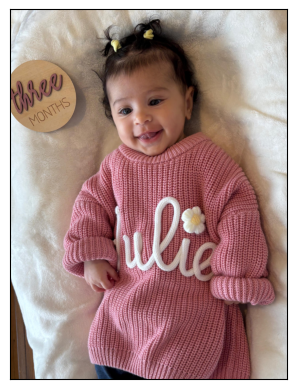

In [48]:
import matplotlib.image as mpimg
img = mpimg.imread('resources/baby_j.jpeg')
imgplot = plt.imshow(img)
imgplot.axes.get_xaxis().set_visible(False)
imgplot.axes.get_yaxis().set_visible(False)
print("Congratulations on finishing Lab 3! 🎉")
print("And here's Baby J at 3 months old! 👶")
print("She's getting pretty good at conditionals! 😊")
print("if someone smiles at Baby J:")
print("    Baby J smiles back! 💕")
plt.show()

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [49]:
grader.check_all()

q1 results: All test cases passed!

q2.0 results: All test cases passed!

q2.1 results: All test cases passed!

q2.2 results: All test cases passed!

q2.3 results: All test cases passed!

q3.0 results: All test cases passed!

q3.1 results: All test cases passed!

q3.2 results: All test cases passed!

q3.3 results: All test cases passed!

q4.0 results: All test cases passed!

q4.1 results: All test cases passed!

q4.2 results: All test cases passed!

q4.3 results: All test cases passed!

q5 results: All test cases passed!

q6 results: All test cases passed!

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

Make sure you submit the .zip file to Gradescope.

In [50]:
# Save your notebook first, then run this cell to export your submission.
grader.export(pdf=False)